<a href="https://colab.research.google.com/github/Lomemoraine/RESEARCHEXPERIMENTS/blob/main/SWATresearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import normal data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import datetime
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split


2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df1= pd.read_csv("/content/drive/MyDrive/THESISDOCUMENTS/DATASETS/SWAT DATASET/SWaT_Dataset_Normal_v0.csv")
# df2= pd.read_csv("/content/drive/MyDrive/THESISDOCUMENTS/DATASETS/SWAT DATASET/SWaT_Dataset_Normal_v1.csv")
df3 = pd.read_csv("/content/drive/MyDrive/THESISDOCUMENTS/DATASETS/SWAT DATASET/SWaT.csv")


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496800 entries, 0 to 496799
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0    Timestamp     496800 non-null  object 
 1   FIT101         496800 non-null  float64
 2   LIT101         496800 non-null  float64
 3   MV101          496800 non-null  int64  
 4   P101           496800 non-null  int64  
 5   P102           496800 non-null  int64  
 6   AIT201         496800 non-null  float64
 7   AIT202         496800 non-null  float64
 8   AIT203         496800 non-null  float64
 9   FIT201         496800 non-null  float64
 10  MV201          496800 non-null  int64  
 11  P201           496800 non-null  int64  
 12  P202           496800 non-null  int64  
 13  P203           496800 non-null  int64  
 14  P204           496800 non-null  int64  
 15  P205           496800 non-null  int64  
 16  P206           496800 non-null  int64  
 17  DPIT301        496800 non-nul

In [5]:
df1["Normal/Attack"].nunique()

# df3["Normal/Attack"].value_counts() --This is the test data and I actually should standardize it

1

In [6]:
df1.shape


(496800, 53)

In [7]:
df3['Normal/Attack'] = df3['Normal/Attack'].replace('A ttack', 'Attack')

In [8]:
df3['Normal/Attack'].unique()

array(['Normal', 'Attack'], dtype=object)

In [9]:
df3.head(5)

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [10]:
# Standardize column names
df3.columns = df3.columns.str.strip()
df1.columns = df1.columns.str.strip()


In [11]:
# Parse timestamps & sort for training dataset

if ' Timestamp' in df1.columns:
    df1.rename(columns={' Timestamp': 'Timestamp'}, inplace=True)

df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], errors='coerce')
df1.sort_values(by='Timestamp', inplace=True)

/tmp/ipykernel_810/1844804422.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], errors='coerce')


In [12]:
# Parse timestamps & sort for test dataset

if ' Timestamp' in df3.columns:
    df3.rename(columns={' Timestamp': 'Timestamp'}, inplace=True)

df3['Timestamp'] = pd.to_datetime(df3['Timestamp'], errors='coerce')
df3.sort_values(by='Timestamp', inplace=True)

/tmp/ipykernel_810/1266782434.py:6: UserWarning: Parsing dates in  %d/%m/%Y %I:%M:%S %p format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df3['Timestamp'] = pd.to_datetime(df3['Timestamp'], errors='coerce')


In [13]:
# Encode labels (Normal=0, Attack=1) training dataset

if 'Normal/Attack' in df1.columns:
    df1['Label'] = df1['Normal/Attack'].apply(lambda x: 0 if x.strip().lower() == 'normal' else 1)
else:
    raise ValueError("Label column 'Normal/Attack' not found in dataset!")

print(df1['Label'].value_counts())

Label
0    496800
Name: count, dtype: int64


In [14]:
# Encode labels (Normal=0, Attack=1) evaluation dataset

if 'Normal/Attack' in df3.columns:
    df3['Label'] = df3['Normal/Attack'].apply(lambda x: 0 if x.strip().lower() == 'normal' else 1)
else:
    raise ValueError("Label column 'Normal/Attack' not found in dataset!")

print(df3['Label'].value_counts())

Label
0    395298
1     54621
Name: count, dtype: int64


In [15]:
df3.drop(columns=['Normal/Attack'], inplace=True)
df1.drop(columns=['Normal/Attack'], inplace=True)

In [16]:
df1['Label'].unique()

array([0])

In [17]:
df1.head(5)

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Label
0,2015-12-22 16:00:00,2.470294,261.5804,2,2,1,244.3284,8.19008,306.101,2.471278,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,0
1,2015-12-22 16:00:01,2.457163,261.1879,2,2,1,244.3284,8.19008,306.101,2.468587,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,0
2,2015-12-22 16:00:02,2.439548,260.9131,2,2,1,244.3284,8.19008,306.101,2.467305,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,0
3,2015-12-22 16:00:03,2.428338,260.2850,2,2,1,244.3284,8.19008,306.101,2.466536,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,0
4,2015-12-22 16:00:04,2.424815,259.8925,2,2,1,244.4245,8.19008,306.101,2.466536,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,0


In [18]:
# Check for missing values
missing_summary = df1.isnull().sum()

# Print only columns with missing values
print(missing_summary[missing_summary > 0])


Series([], dtype: int64)


In [19]:
# # Handle missing values
# # Option: Forward-fill, then drop remaining NaNs
# df1.fillna(method='ffill', inplace=True)
# df1.dropna(inplace=True)
# df3.fillna(method='ffill', inplace=True)
# df3.dropna(inplace=True)

In [20]:
df1.to_csv("SWaT_Dataset_Normal_v0_preprocessed.csv", index=False)
df3.to_csv("SWaT_preprocessedevaluation.csv", index=False)

# **Feature Preparation,and training data splitting**

In [21]:
df1 = pd.read_csv("SWaT_Dataset_Normal_v0_preprocessed.csv")
df3 = pd.read_csv("SWaT_preprocessedevaluation.csv")

In [31]:
# Display basic information
print("Training Dataset Shape:", df1.shape)
print("Test Dataset Shape:", df3.shape)
print("\nTraining Dataset Labels:")
print(df1['Label'].value_counts())
print("\nTest Dataset Labels:")
print(df3['Label'].value_counts())

Training Dataset Shape: (496800, 53)
Test Dataset Shape: (449919, 53)

Training Dataset Labels:
Label
0    496800
Name: count, dtype: int64

Test Dataset Labels:
Label
0    395298
1     54621
Name: count, dtype: int64


In [23]:
# feature_cols = [col for col in df1.columns if col not in ['Timestamp', 'Label']]
# print(f"\nNumber of features: {len(feature_cols)}")
# print("Feature columns:", feature_cols[:10], "...")
# Define feature columns (drop Timestamp and Label)
feature_cols = [col for col in df1.columns if col not in ['Timestamp', 'Label']]

print(f"\nNumber of features: {len(feature_cols)}")
print("Feature columns:", feature_cols[:10], "...")

# Separate features and labels
X = df1[feature_cols].values
y = df1['Label'].values



Number of features: 51
Feature columns: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201'] ...


In [24]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (397440, 51)
Test set shape: (99360, 51)


In [25]:
# Define feature columns (drop Timestamp and Label) for Evaluation Set
feature_colseval = [col for col in df3.columns if col not in ['Timestamp', 'Label']]

print(f"\nNumber of features: {len(feature_cols)}")
print("Feature columns:", feature_cols[:10], "...")

# Separate features and labels
X = df3[feature_colseval].values
y = df3['Label'].values


Number of features: 51
Feature columns: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201'] ...


In [26]:
from sklearn.feature_selection import VarianceThreshold

# Fit selector on training set (normal only)
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train)

# Apply the same selector to test set (already split)
X_test_selected = selector.transform(X_test)

# Apply the same selector to evaluation set (no splitting, full file)
X_eval_selected = selector.transform(X)

# Get the names of selected features
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selector.get_support()[i]]

print("Selected features:", selected_features[:10], "...")
num_selected = len(selected_features)
print(f"Number of features selected: {num_selected}")

Selected features: ['FIT101', 'LIT101', 'MV101', 'P101', 'AIT201', 'AIT203', 'FIT201', 'MV201', 'P203', 'P205'] ...
Number of features selected: 31


In [27]:
# # Convert training set back to DataFrame for correlation analysis
# X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
# # Compute correlation matrix
# corr_matrix = X_train_df.corr().abs()
# # Keep only upper triangle of correlation matrix
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# # Identify features to drop (correlation > 0.95)
# to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
# # Drop redundant features
# X_train_reduced = X_train_df.drop(columns=to_drop)
# X_test_reduced = pd.DataFrame(X_test_selected, columns=selected_features).drop(columns=to_drop)

# print(f"Number of features after correlation filter: {X_train_reduced.shape[1]}")
# print("Dropped due to correlation:", to_drop)
import numpy as np
import pandas as pd

# Compute correlation matrix on training set (after variance threshold)
X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
corr_matrix = X_train_df.corr()

# Keep only upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify features to drop (correlation > 0.95)
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Apply to training set
X_train_reduced = X_train_df.drop(columns=to_drop)

# Apply to test set
X_test_reduced = pd.DataFrame(X_test_selected, columns=selected_features).drop(columns=to_drop)

# Apply to evaluation set (no splitting, full file)
X_eval_reduced = pd.DataFrame(X_eval_selected, columns=selected_features).drop(columns=to_drop)

print(f"Number of features after correlation filter: {X_train_reduced.shape[1]}")
print("Dropped due to correlation:", to_drop)


Number of features after correlation filter: 20
Dropped due to correlation: ['MV101', 'FIT201', 'MV201', 'P203', 'FIT301', 'P302', 'AIT502', 'FIT501', 'FIT502', 'PIT501', 'PIT503']


In [28]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import time

# Train only on normal samples
X_train_normal = X_train_reduced[y_train == 0]

# Validation set: normal only (to tune contamination)
X_val_normal = X_test_reduced[y_test == 0]

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_normal)

# --- Validation (normal only) ---
y_val_pred = iso_forest.predict(X_val_normal)
y_val_pred = (y_val_pred == -1).astype(int)

print("Validation results (normal only):")
print(classification_report([0]*len(y_val_pred), y_val_pred))

# --- Evaluation (mixed normal + anomalies) ---
y_eval = df3['Label'].values  # labels from evaluation dataset

start = time.perf_counter()
y_eval_pred = iso_forest.predict(X_eval_reduced)
end = time.perf_counter()

y_eval_pred = (y_eval_pred == -1).astype(int)

print("\nEvaluation results (mixed dataset):")
print(classification_report(y_eval, y_eval_pred))

# Extra metrics
roc_auc = roc_auc_score(y_eval, y_eval_pred)
pr_auc = average_precision_score(y_eval, y_eval_pred)
latency = (end - start) / len(X_eval_reduced) * 1000  # ms per sample

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Average latency per sample: {latency:.4f} ms")


Validation results (normal only):
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     99360
           1       0.00      0.00      0.00         0

    accuracy                           0.95     99360
   macro avg       0.50      0.47      0.49     99360
weighted avg       1.00      0.95      0.97     99360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation results (mixed dataset):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94    395298
           1       0.56      0.67      0.61     54621

    accuracy                           0.90    449919
   macro avg       0.76      0.80      0.78    449919
weighted avg       0.91      0.90      0.90    449919

ROC-AUC: 0.7997
PR-AUC: 0.4171
Average latency per sample: 0.0025 ms


In [29]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import time

contamination_values = [0.01, 0.05, 0.10]

for c in contamination_values:
    iso_forest = IsolationForest(contamination=c, random_state=42)
    iso_forest.fit(X_train_normal)

    start = time.perf_counter()
    y_eval_pred = iso_forest.predict(X_eval_reduced)
    end = time.perf_counter()

    y_eval_pred = (y_eval_pred == -1).astype(int)

    latency = (end - start) / len(X_eval_reduced) * 1000

    print(f"\n=== Contamination: {c} ===")
    print(classification_report(y_eval, y_eval_pred))
    print(f"ROC-AUC: {roc_auc_score(y_eval, y_eval_pred):.4f}")
    print(f"PR-AUC: {average_precision_score(y_eval, y_eval_pred):.4f}")
    print(f"Average latency per sample: {latency:.4f} ms")


=== Contamination: 0.01 ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    395298
           1       0.98      0.59      0.73     54621

    accuracy                           0.95    449919
   macro avg       0.96      0.79      0.85    449919
weighted avg       0.95      0.95      0.94    449919

ROC-AUC: 0.7924
PR-AUC: 0.6234
Average latency per sample: 0.0025 ms

=== Contamination: 0.05 ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94    395298
           1       0.56      0.67      0.61     54621

    accuracy                           0.90    449919
   macro avg       0.76      0.80      0.78    449919
weighted avg       0.91      0.90      0.90    449919

ROC-AUC: 0.7997
PR-AUC: 0.4171
Average latency per sample: 0.0040 ms

=== Contamination: 0.1 ===
              precision    recall  f1-score   support

           0       0.96      0.80      0.87    395298
           1 

In [30]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import time

nu_values = [0.01, 0.05, 0.10]

X_train_normal = X_train_reduced[y_train == 0]
y_eval = df3['Label'].values  # labels from evaluation dataset

for nu in nu_values:
    oc_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    oc_svm.fit(X_train_normal)

    start = time.perf_counter()
    y_eval_pred = oc_svm.predict(X_eval_reduced)
    end = time.perf_counter()

    y_eval_pred = (y_eval_pred == -1).astype(int)

    print(f"\n=== nu: {nu} ===")
    print(classification_report(y_eval, y_eval_pred))

    roc_auc = roc_auc_score(y_eval, y_eval_pred)
    pr_auc = average_precision_score(y_eval, y_eval_pred)
    latency = (end - start) / len(X_eval_reduced) * 1000

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Average latency per sample: {latency:.4f} ms")




=== nu: 0.01 ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95    395298
           1       0.65      0.67      0.66     54621

    accuracy                           0.92    449919
   macro avg       0.80      0.81      0.81    449919
weighted avg       0.92      0.92      0.92    449919

ROC-AUC: 0.8112
PR-AUC: 0.4789
Average latency per sample: 0.2274 ms

=== nu: 0.05 ===
              precision    recall  f1-score   support

           0       0.96      0.89      0.92    395298
           1       0.47      0.71      0.57     54621

    accuracy                           0.87    449919
   macro avg       0.71      0.80      0.74    449919
weighted avg       0.90      0.87      0.88    449919

ROC-AUC: 0.7992
PR-AUC: 0.3685
Average latency per sample: 1.1629 ms

=== nu: 0.1 ===
              precision    recall  f1-score   support

           0       0.96      0.79      0.87    395298
           1       0.33      0.75      0.46   

In [32]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import time

# Calculate scale_pos_weight = (# normal / # anomalies)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm = lgb.LGBMClassifier(
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# Train on full dataset (both classes)
lgbm.fit(X_train_reduced, y_train)

# --- Evaluation ---
y_eval = df3['Label'].values

start = time.perf_counter()
y_eval_pred = lgbm.predict(X_eval_reduced)
end = time.perf_counter()

latency = (end - start) / len(X_eval_reduced) * 1000

print("\nEvaluation results (LightGBM):")
print(classification_report(y_eval, y_eval_pred))

roc_auc = roc_auc_score(y_eval, y_eval_pred)
pr_auc = average_precision_score(y_eval, y_eval_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Average latency per sample: {latency:.4f} ms")


/tmp/ipykernel_810/981568671.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 397440
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138016 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3059
[LightGBM] [Info] Number of data points in the train set: 397440, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# # Since this is semi-supervised, we only use NORMAL data for training
# # Split df1 into 80% training and 20% validation

# # Calculate split index (80% of data)
# split_idx = int(0.8 * len(df1))

# # Split the data temporally (maintaining time order)
# train_data = df1.iloc[:split_idx].copy()
# val_data = df1.iloc[split_idx:].copy()
# print(f"Training samples: {len(train_data)}")
# print(f"Validation samples: {len(val_data)}")
# print(f"Test samples: {len(df3)}")

Training samples: 397440
Validation samples: 99360
Test samples: 449919


In [ ]:
# # Verify all training data is normal
# print(f"\nTraining set - Normal: {(train_data['Label'] == 0).sum()}, Attack: {(train_data['Label'] == 1).sum()}")
# print(f"Validation set - Normal: {(val_data['Label'] == 0).sum()}, Attack: {(val_data['Label'] == 1).sum()}")
# print(f"Test set - Normal: {(df3['Label'] == 0).sum()}, Attack: {(df3['Label'] == 1).sum()}")


Training set - Normal: 397440, Attack: 0
Validation set - Normal: 99360, Attack: 0
Test set - Normal: 395298, Attack: 54621


### **Feature Scaling**

In [ ]:
# Extract features for scaling
X_train = train_data[feature_cols].values
X_val = val_data[feature_cols].values
X_test = df3[feature_cols].values

In [ ]:

# Extract labels
y_train = train_data['Label'].values
y_val = val_data['Label'].values
y_test = df3['Label'].values

In [ ]:
# Normalize features using MinMaxScaler (fit only on training data)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled validation data shape: {X_val_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

Scaled training data shape: (397440, 51)
Scaled validation data shape: (99360, 51)
Scaled test data shape: (449919, 51)


# **DIMENSIONALITY REDUCTION(PCA)**

In [ ]:
from sklearn.decomposition import PCA

# Determine optimal number of components (e.g., 95% variance)
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

Original number of features: 51
Reduced number of features: 8
Explained variance ratio: 0.9548


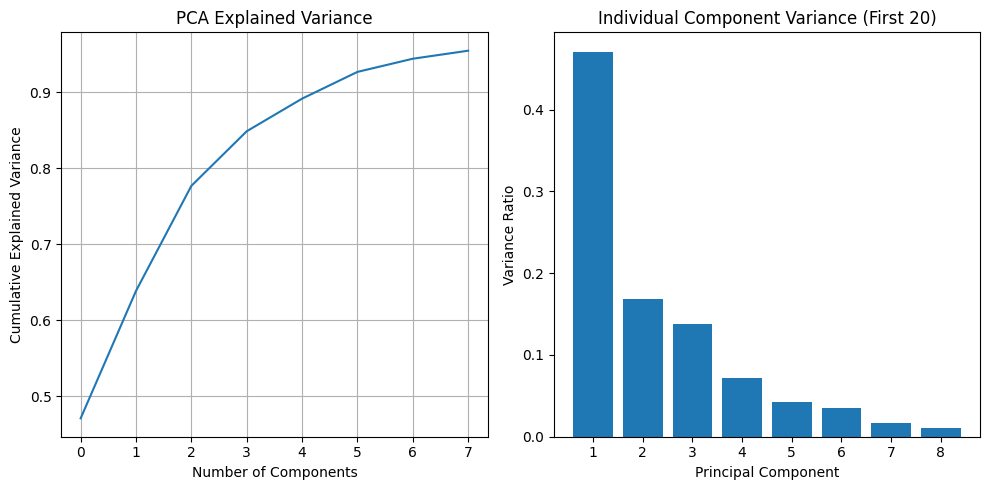

In [ ]:
# Visualize explained variance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, min(21, len(pca.explained_variance_ratio_) + 1)),
        pca.explained_variance_ratio_[:20])
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Individual Component Variance (First 20)')
plt.tight_layout()
plt.show()

# **Deep Neural Network Architecture**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Build DNN architecture
def build_dnn_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )

    return model

# Create model
input_dim = X_train_pca.shape[1]
model = build_dnn_model(input_dim)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,489 (185.50 KB)

 Trainable params: 46,529 (181.75 KB)

 Non-trainable params: 960 (3.75 KB)

## **Train DNN**

Epoch 1/10
3105/3105 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9881 - auc: 0.0000e+00 - loss: 0.0406 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.7697e-04 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
3105/3105 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 1.4136e-04 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.6135e-05 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
3105/3105 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 2.0594e-05 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 2.6321e-06 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
3105/3105 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 3

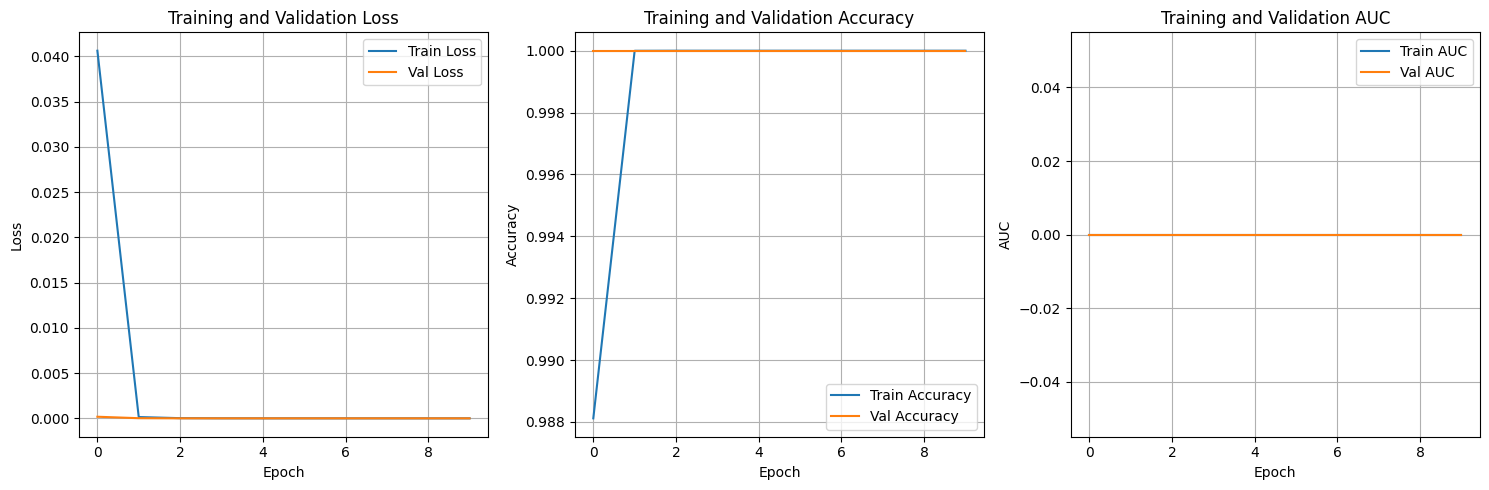

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluation**

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

# Predict on test set
y_pred_proba = model.predict(X_test_pca)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
auc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("TEST SET PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:    {accuracy*100:.2f}%")
print(f"Precision:   {precision*100:.2f}%")
print(f"Recall:      {recall*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")
print(f"F1-Score:    {f1*100:.2f}%")
print(f"AUC:         {auc*100:.2f}%")
print("="*60)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Normal', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

14060/14060 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step
TEST SET PERFORMANCE METRICS
Accuracy:    87.86%
Precision:   0.00%
Recall:      0.00%
Specificity: 100.00%
F1-Score:    0.00%
AUC:         21.20%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      1.00      0.94    395298
      Attack       0.00      0.00      0.00     54621

    accuracy                           0.88    449919
   macro avg       0.44      0.50      0.47    449919
weighted avg       0.77      0.88      0.82    449919


Confusion Matrix:
TN: 395298, FP: 0
FN: 54621, TP: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

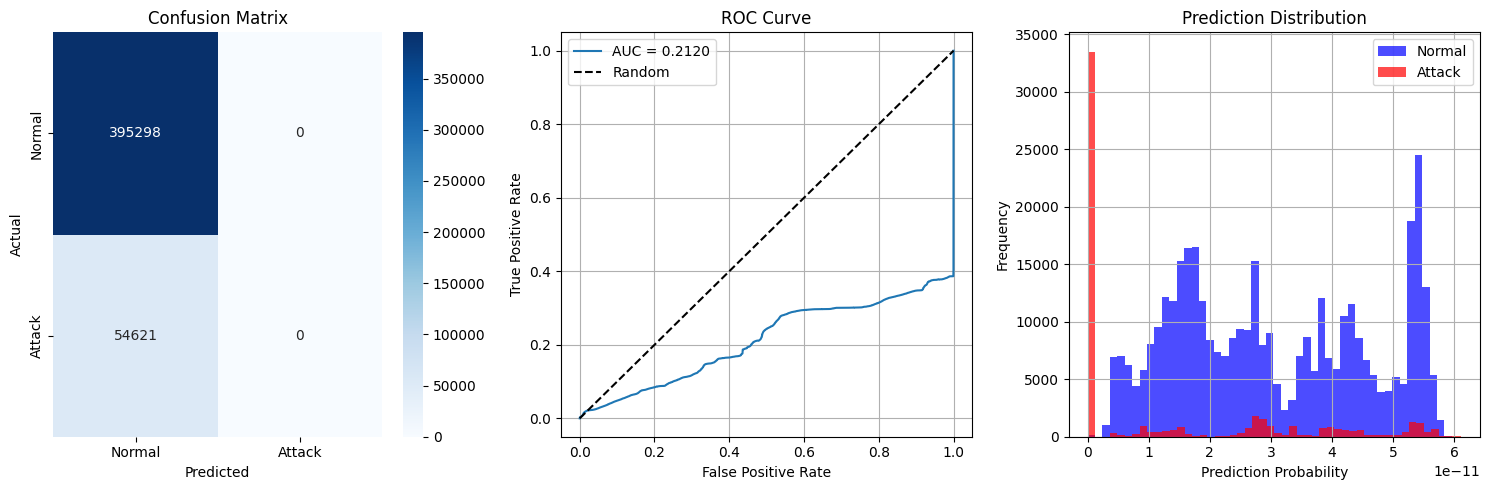

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# Prediction distribution
plt.subplot(1, 3, 3)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.title('Prediction Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# Since we're doing semi-supervised, train ONLY on normal data from training set
X_train_normal = X_train_pca[y_train == 0]

print(f"Training Isolation Forest on {len(X_train_normal)} normal samples from training set")
print(f"Testing on {len(X_test_pca)} samples from df3 test set")

# Build and train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.1,  # Expected proportion of anomalies
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

iso_forest.fit(X_train_normal)

# Predict on df3 test set
test_scores = iso_forest.decision_function(X_test_pca)  # Higher score = more normal
test_predictions = iso_forest.predict(X_test_pca)  # 1 = normal, -1 = anomaly

# Convert predictions to match our label convention (0=normal, 1=attack)
y_pred_iso = (test_predictions == -1).astype(int)

# Calculate metrics for Isolation Forest on df3 test set
accuracy_iso = accuracy_score(y_test, y_pred_iso)
precision_iso = precision_score(y_test, y_pred_iso)
recall_iso = recall_score(y_test, y_pred_iso)
f1_iso = f1_score(y_test, y_pred_iso)
auc_iso = roc_auc_score(y_test, -test_scores)  # Use negative scores since lower = more anomalous

print("="*60)
print("ISOLATION FOREST - DF3 TEST SET PERFORMANCE")
print("="*60)
print(f"Accuracy:    {accuracy_iso*100:.2f}%")
print(f"Precision:   {precision_iso*100:.2f}%")
print(f"Recall:      {recall_iso*100:.2f}%")
print(f"F1-Score:    {f1_iso*100:.2f}%")
print(f"AUC:         {auc_iso*100:.2f}%")
print("="*60)

print("\nClassification Report (df3 test set):")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Attack']))

cm_iso = confusion_matrix(y_test, y_pred_iso)
print("\nConfusion Matrix (df3 test set):")
print(f"TN: {cm_iso[0,0]}, FP: {cm_iso[0,1]}")
print(f"FN: {cm_iso[1,0]}, TP: {cm_iso[1,1]}")

Training Isolation Forest on 397440 normal samples from training set
Testing on 449919 samples from df3 test set


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s


ISOLATION FOREST - DF3 TEST SET PERFORMANCE
Accuracy:    40.55%
Precision:   15.64%
Recall:      88.67%
F1-Score:    26.58%
AUC:         80.95%

Classification Report (df3 test set):
              precision    recall  f1-score   support

      Normal       0.96      0.34      0.50    395298
      Attack       0.16      0.89      0.27     54621

    accuracy                           0.41    449919
   macro avg       0.56      0.61      0.38    449919
weighted avg       0.86      0.41      0.47    449919


Confusion Matrix (df3 test set):
TN: 133995, FP: 261303
FN: 6190, TP: 48431


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.8s finished


## One class svm

In [ ]:
from sklearn.svm import OneClassSVM

# Build and train One-Class SVM (trained only on normal data from training set)
oc_svm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.01,  # Upper bound on fraction of training errors
    cache_size=1000,
    verbose=True
)

print(f"Training One-Class SVM on {len(X_train_normal)} normal samples from training set")
print(f"Testing on {len(X_test_pca)} samples from df3 test set")

oc_svm.fit(X_train_normal)

# Predict on df3 test set
test_scores_svm = oc_svm.decision_function(X_test_pca)  # Higher score = more normal
test_predictions_svm = oc_svm.predict(X_test_pca)  # 1 = normal, -1 = anomaly

# Convert predictions to match our label convention
y_pred_svm = (test_predictions_svm == -1).astype(int)

# Calculate metrics for One-Class SVM on df3 test set
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, -test_scores_svm)

print("="*60)
print("ONE-CLASS SVM - DF3 TEST SET PERFORMANCE")
print("="*60)
print(f"Accuracy:    {accuracy_svm*100:.2f}%")
print(f"Precision:   {precision_svm*100:.2f}%")
print(f"Recall:      {recall_svm*100:.2f}%")
print(f"F1-Score:    {f1_svm*100:.2f}%")
print(f"AUC:         {auc_svm*100:.2f}%")
print("="*60)

print("\nClassification Report (df3 test set):")
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Attack']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix (df3 test set):")
print(f"TN: {cm_svm[0,0]}, FP: {cm_svm[0,1]}")
print(f"FN: {cm_svm[1,0]}, TP: {cm_svm[1,1]}")

Training One-Class SVM on 397440 normal samples from training set
Testing on 449919 samples from df3 test set
[LibSVM]============================================================
ONE-CLASS SVM - DF3 TEST SET PERFORMANCE
Accuracy:    36.26%
Precision:   14.71%
Recall:      88.56%
F1-Score:    25.23%
AUC:         67.76%

Classification Report (df3 test set):
              precision    recall  f1-score   support

      Normal       0.95      0.29      0.44    395298
      Attack       0.15      0.89      0.25     54621

    accuracy                           0.36    449919
   macro avg       0.55      0.59      0.35    449919
weighted avg       0.85      0.36      0.42    449919


Confusion Matrix (df3 test set):
TN: 114788, FP: 280510
FN: 6251, TP: 48370


def tune_isolation_forest_with_val(X_train_normal, X_val_pca, y_val, X_test_pca, y_test):
    """Tune Isolation Forest using validation set, then evaluate on df3 test set"""

    param_grid = {

```
# This is formatted as code
```


        'contamination': [0.05, 0.1, 0.15, 0.2],
        'n_estimators': [50, 100, 200],
        'max_samples': [0.1, 0.5, 'auto']
    }

    best_score = -1
    best_params = {}
    best_model = None

    print("Tuning Isolation Forest parameters...")

    # Manual grid search using validation set
    for contamination in param_grid['contamination']:
        for n_estimators in param_grid['n_estimators']:
            for max_samples in param_grid['max_samples']:

                model = IsolationForest(
                    n_estimators=n_estimators,
                    max_samples=max_samples,
                    contamination=contamination,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(X_train_normal)
                val_predictions = model.predict(X_val_pca)
                val_predictions_binary = (val_predictions == -1).astype(int)
                score = f1_score(y_val, val_predictions_binary)

                if score > best_score:
                    best_score = score
                    best_params = {
                        'contamination': contamination,
                        'n_estimators': n_estimators,
                        'max_samples': max_samples
                    }
                    best_model = model

    print(f"Best F1-Score on validation set: {best_score:.4f}")
    print(f"Best parameters: {best_params}")

    # Evaluate best model on df3 test set
    test_predictions = best_model.predict(X_test_pca)
    test_predictions_binary = (test_predictions == -1).astype(int)

    test_accuracy = accuracy_score(y_test, test_predictions_binary)
    test_precision = precision_score(y_test, test_predictions_binary)
    test_recall = recall_score(y_test, test_predictions_binary)
    test_f1 = f1_score(y_test, test_predictions_binary)

    print("\n" + "="*60)
    print("TUNED ISOLATION FOREST - DF3 TEST SET PERFORMANCE")
    print("="*60)
    print(f"Accuracy:  {test_accuracy*100:.2f}%")
    print(f"Precision: {test_precision*100:.2f}%")
    print(f"Recall:    {test_recall*100:.2f}%")
    print(f"F1-Score:  {test_f1*100:.2f}%")
    print("="*60)

    return best_model, best_params

# Tune and evaluate on df3 test set
best_iso_forest, best_params = tune_isolation_forest_with_val(
    X_train_normal, X_val_pca, y_val, X_test_pca, y_test
)

## Optimized one class svm

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Custom scorer for one-class SVM (using a subset for speed)
def ocsvm_f1_scorer(estimator, X, y):
    predictions = estimator.predict(X)
    y_pred = (predictions == -1).astype(int)
    return f1_score(y, y_pred)

# Use a subset of validation data for grid search (for speed)
val_subset_size = 50000
X_val_subset = X_val_pca[:val_subset_size]
y_val_subset = y_val[:val_subset_size]

print(f"Grid searching on validation subset of {val_subset_size} samples...")

# Define parameter grid
param_grid = {
    'nu': [0.01, 0.05, 0.1, 0.15],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

# Perform grid search
best_f1 = 0
best_params = None
best_model = None

for nu in param_grid['nu']:
    for gamma in param_grid['gamma']:
        print(f"\nTrying nu={nu}, gamma={gamma}")

        # Train model
        ocsvm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma, cache_size=1000)
        ocsvm.fit(X_train_pca)

        # Predict on validation set
        val_pred = ocsvm.predict(X_val_subset)
        y_pred_val = (val_pred == -1).astype(int)

        # Calculate F1
        f1 = f1_score(y_val_subset, y_pred_val)
        accuracy = accuracy_score(y_val_subset, y_pred_val)

        print(f"  F1: {f1*100:.2f}%, Accuracy: {accuracy*100:.2f}%")

        if f1 > best_f1:
            best_f1 = f1
            best_params = {'nu': nu, 'gamma': gamma}
            best_model = ocsvm

print("\n" + "="*80)
print(f"Best Parameters: {best_params}")
print(f"Best Validation F1: {best_f1*100:.2f}%")
print("="*80)

In [ ]:
#Evaluate best model on test set
test_pred_best = best_model.predict(X_test_pca)
test_scores_best = best_model.decision_function(X_test_pca)
y_pred_best = (test_pred_best == -1).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
specificity = recall_score(y_test, y_pred_best, pos_label=0)
f1 = f1_score(y_test, y_pred_best)
auc = roc_auc_score(y_test, -test_scores_best)

print("\n" + "="*80)
print("OPTIMIZED ONE-CLASS SVM - TEST SET PERFORMANCE")
print("="*80)
print(f"Parameters: {best_params}")
print(f"Accuracy:    {accuracy*100:.2f}%")
print(f"Precision:   {precision*100:.2f}%")
print(f"Recall:      {recall*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")
print(f"F1-Score:    {f1*100:.2f}%")
print(f"AUC:         {auc*100:.2f}%")
print("="*80)

cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(f"TN: {cm[0,0]:,}, FP: {cm[0,1]:,}")
print(f"FN: {cm[1,0]:,}, TP: {cm[1,1]:,}")